# 04 — Business Address EDA

This notebook performs detailed exploratory analysis of the `business_address`
field across all training and test source datasets.

Objectives:

1. Measure address completeness.
2. Analyze missing, empty, and whitespace-only addresses.
3. Analyze address length and structure.
4. Identify exact duplicate addresses.
5. Analyze normalized address patterns.
6. Identify suspicious address values.
7. Compare address quality across sources.
8. Analyze country-address relationships.
9. Identify characteristics useful for entity resolution / record linkage.
10. Produce reusable EDA outputs without loading the full datasets into memory.

Large datasets are queried using DuckDB.

In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
CURRENT_DIR = Path.cwd()

DATA_DIR = CURRENT_DIR.parent / "dataset"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

OUTPUT_DIR = CURRENT_DIR.parent / "eda_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "train_source1": TRAIN_DIR / "train_source1.tsv",
    "train_source2": TRAIN_DIR / "train_source2.tsv",
    "train_source3": TRAIN_DIR / "train_source3.tsv",
    "train_ground_truth": TRAIN_DIR / "train_ground_truth.tsv",
    "test_source1": TEST_DIR / "test_source1.tsv",
    "test_source2": TEST_DIR / "test_source2.tsv",
    "test_source3": TEST_DIR / "test_source3.tsv",
}

SOURCE_DATASETS = [
    "train_source1",
    "train_source2",
    "train_source3",
    "test_source1",
    "test_source2",
    "test_source3",
]

TRAIN_SOURCE_DATASETS = [
    "train_source1",
    "train_source2",
    "train_source3",
]

TEST_SOURCE_DATASETS = [
    "test_source1",
    "test_source2",
    "test_source3",
]

print("Current directory:", CURRENT_DIR.resolve())
print("Data directory:", DATA_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())

Current directory: C:\Projects\amazon-ml-challenge-2026-main\student_resource\eda
Data directory: C:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset
Output directory: C:\Projects\amazon-ml-challenge-2026-main\student_resource\eda_outputs


In [3]:
for name, path in FILES.items():
    print(f"{name:20} -> {path}")
    print(f"{'':20}    exists = {path.exists()}")
    print()

train_source1        -> c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\train\train_source1.tsv
                        exists = True

train_source2        -> c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\train\train_source2.tsv
                        exists = True

train_source3        -> c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\train\train_source3.tsv
                        exists = True

train_ground_truth   -> c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\train\train_ground_truth.tsv
                        exists = True

test_source1         -> c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\test\test_source1.tsv
                        exists = True

test_source2         -> c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\test\test_source2.tsv
                        exists = True

test_source3         -> c:\Projects\amazon-ml-challenge-2026-main\student_r

In [4]:
con = duckdb.connect()

print("DuckDB version:", duckdb.__version__)

DuckDB version: 1.5.5


In [5]:
def sql_path(path):
    return str(path.resolve()).replace("\\", "/").replace("'", "''")


def source_relation(dataset_name):
    path = FILES[dataset_name]
    
    return f"""
        read_csv_auto(
            '{sql_path(path)}',
            delim='\\t',
            header=true,
            all_varchar=true
        )
    """

In [6]:
for name in SOURCE_DATASETS:
    query = f"""
        DESCRIBE SELECT *
        FROM {source_relation(name)}
    """
    
    schema = con.execute(query).df()
    
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    
    display(schema)


train_source1


,column_name,column_type,null,key,default,extra
0,entity_id,VARCHAR,YES,None,None,None
1,business_name,VARCHAR,YES,None,None,None
2,business_address,VARCHAR,YES,None,None,None
3,country,VARCHAR,YES,None,None,None



train_source2


,column_name,column_type,null,key,default,extra
0,entity_id,VARCHAR,YES,None,None,None
1,business_name,VARCHAR,YES,None,None,None
2,business_address,VARCHAR,YES,None,None,None
3,country,VARCHAR,YES,None,None,None



train_source3


...

,column_name,column_type,null,key,default,extra
0,entity_id,VARCHAR,YES,None,None,None
1,business_name,VARCHAR,YES,None,None,None
2,business_address,VARCHAR,YES,None,None,None
3,country,VARCHAR,YES,None,None,None



test_source2


,column_name,column_type,null,key,default,extra
0,entity_id,VARCHAR,YES,None,None,None
1,business_name,VARCHAR,YES,None,None,None
2,business_address,VARCHAR,YES,None,None,None
3,country,VARCHAR,YES,None,None,None



test_source3


,column_name,column_type,null,key,default,extra
0,entity_id,VARCHAR,YES,None,None,None
1,business_name,VARCHAR,YES,None,None,None
2,business_address,VARCHAR,YES,None,None,None
3,country,VARCHAR,YES,None,None,None


In [7]:
address_quality = []

for name in SOURCE_DATASETS:
    
    query = f"""
        SELECT
            COUNT(*) AS total_rows,

            COUNT(*) FILTER (
                WHERE business_address IS NULL
            ) AS null_address,

            COUNT(*) FILTER (
                WHERE business_address = ''
            ) AS empty_address,

            COUNT(*) FILTER (
                WHERE business_address IS NOT NULL
                  AND TRIM(business_address) = ''
            ) AS whitespace_only_address,

            COUNT(*) FILTER (
                WHERE business_address IS NOT NULL
                  AND TRIM(business_address) <> ''
            ) AS non_empty_address

        FROM {source_relation(name)}
    """
    
    result = con.execute(query).df()
    result.insert(0, "dataset", name)
    
    result["null_pct"] = (
        result["null_address"] / result["total_rows"] * 100
    )
    
    result["empty_or_blank_pct"] = (
        (
            result["null_address"]
            + result["empty_address"]
            + result["whitespace_only_address"]
        )
        / result["total_rows"]
        * 100
    )
    
    address_quality.append(result)

address_quality = pd.concat(address_quality, ignore_index=True)

display(address_quality)

,dataset,total_rows,null_address,empty_address,whitespace_only_address,non_empty_address,null_pct,empty_or_blank_pct
0,train_source1,2206821,0,0,0,2206821,0.000000,0.000000
1,train_source2,5034616,168967,0,0,4865649,3.356105,3.356105
2,train_source3,5285603,175916,0,0,5109687,3.328211,3.328211
3,test_source1,1732544,0,0,0,1732544,0.000000,0.000000
4,test_source2,4887273,129408,0,0,4757865,2.647857,2.647857
5,test_source3,5082316,136098,0,0,4946218,2.677874,2.677874


In [8]:
address_quality.to_csv(
    OUTPUT_DIR / "address_quality_summary.csv",
    index=False
)

In [9]:
address_length_summary = []

for name in SOURCE_DATASETS:
    
    query = f"""
        SELECT
            COUNT(*) AS total_rows,

            AVG(LENGTH(TRIM(business_address))) AS mean_length,
            MIN(LENGTH(TRIM(business_address))) AS min_length,
            MAX(LENGTH(TRIM(business_address))) AS max_length,

            MEDIAN(LENGTH(TRIM(business_address))) AS median_length,

            QUANTILE_CONT(
                LENGTH(TRIM(business_address)), 0.25
            ) AS q25_length,

            QUANTILE_CONT(
                LENGTH(TRIM(business_address)), 0.75
            ) AS q75_length,

            QUANTILE_CONT(
                LENGTH(TRIM(business_address)), 0.95
            ) AS q95_length,

            QUANTILE_CONT(
                LENGTH(TRIM(business_address)), 0.99
            ) AS q99_length

        FROM {source_relation(name)}
        WHERE business_address IS NOT NULL
          AND TRIM(business_address) <> ''
    """
    
    result = con.execute(query).df()
    result.insert(0, "dataset", name)
    address_length_summary.append(result)

address_length_summary = pd.concat(
    address_length_summary,
    ignore_index=True
)

display(address_length_summary)
address_length_summary.to_csv(
    OUTPUT_DIR / "address_length_summary.csv",
    index=False
)

,dataset,total_rows,mean_length,min_length,max_length,median_length,q25_length,q75_length,q95_length,q99_length
0,train_source1,2206821,52.066219,11,256,41.0,33.0,70.0,103.0,124.0
1,train_source2,4865649,47.831177,8,249,37.0,31.0,63.0,97.0,118.0
2,train_source3,5109687,48.322719,2,240,42.0,35.0,55.0,92.0,116.0
3,test_source1,1732544,57.213184,11,268,50.0,36.0,74.0,105.0,126.0
4,test_source2,4757865,51.784587,5,269,43.0,32.0,68.0,99.0,120.0
5,test_source3,4946218,50.081597,5,267,44.0,36.0,59.0,95.0,118.0


In [10]:
length_distribution = []

for name in SOURCE_DATASETS:
    
    query = f"""
        SELECT
            CASE
                WHEN business_address IS NULL THEN 'NULL'
                WHEN TRIM(business_address) = '' THEN 'BLANK'
                WHEN LENGTH(TRIM(business_address)) <= 10 THEN '0-10'
                WHEN LENGTH(TRIM(business_address)) <= 25 THEN '11-25'
                WHEN LENGTH(TRIM(business_address)) <= 50 THEN '26-50'
                WHEN LENGTH(TRIM(business_address)) <= 100 THEN '51-100'
                WHEN LENGTH(TRIM(business_address)) <= 200 THEN '101-200'
                ELSE '200+'
            END AS length_bucket,

            COUNT(*) AS row_count

        FROM {source_relation(name)}

        GROUP BY 1
        ORDER BY 1
    """
    
    result = con.execute(query).df()
    result.insert(0, "dataset", name)
    length_distribution.append(result)

length_distribution = pd.concat(
    length_distribution,
    ignore_index=True
)

display(length_distribution)

,dataset,length_bucket,row_count
0,train_source1,101-200,124717
1,train_source1,11-25,54314
2,train_source1,200+,52
3,train_source1,26-50,1303774
4,train_source1,51-100,723964
5,train_source2,0-10,57
6,train_source2,101-200,189278
7,train_source2,11-25,294848
8,train_source2,200+,53
9,train_source2,26-50,2969962


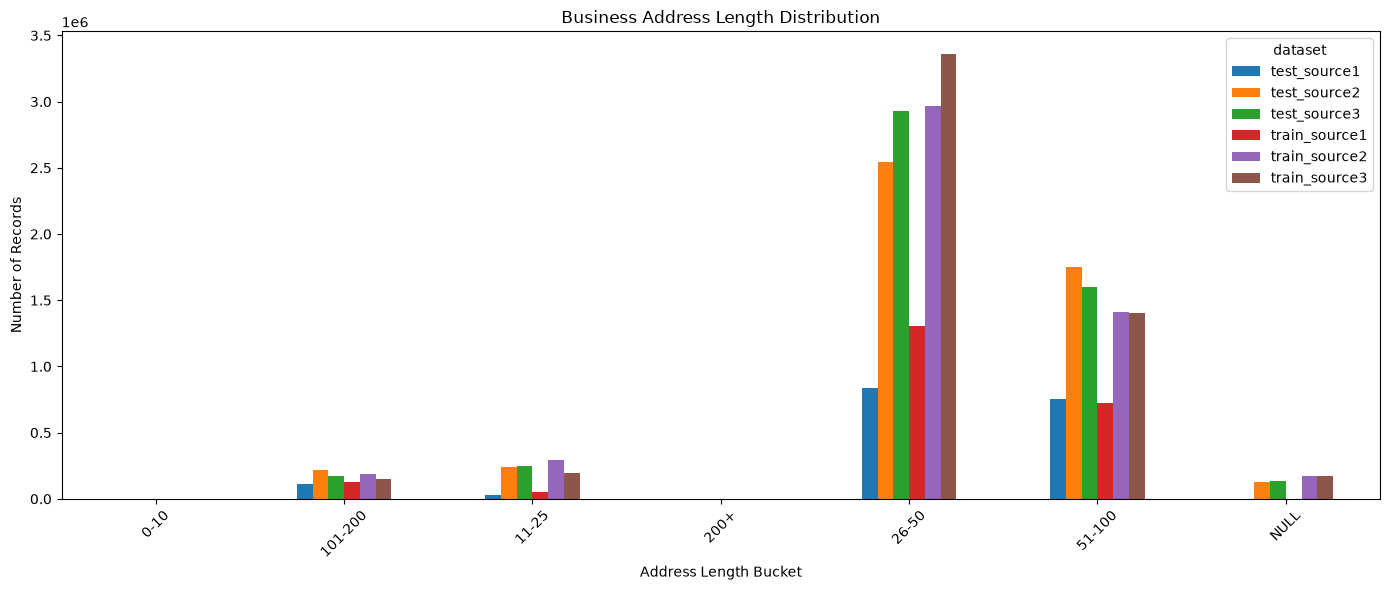

In [11]:
plot_data = length_distribution.pivot(
    index="length_bucket",
    columns="dataset",
    values="row_count"
).fillna(0)

plot_data.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Business Address Length Distribution")
plt.xlabel("Address Length Bucket")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "address_length_distribution.png",
    dpi=150
)

plt.show()

In [12]:
duplicate_address_summary = []

for name in SOURCE_DATASETS:
    
    query = f"""
        SELECT
            COUNT(*) AS non_empty_rows,
            COUNT(DISTINCT TRIM(business_address)) AS unique_addresses,
            COUNT(*) - COUNT(DISTINCT TRIM(business_address))
                AS duplicate_excess_rows

        FROM {source_relation(name)}

        WHERE business_address IS NOT NULL
          AND TRIM(business_address) <> ''
    """
    
    result = con.execute(query).df()
    result.insert(0, "dataset", name)
    
    result["duplicate_excess_pct"] = (
        result["duplicate_excess_rows"]
        / result["non_empty_rows"]
        * 100
    )
    
    duplicate_address_summary.append(result)

duplicate_address_summary = pd.concat(
    duplicate_address_summary,
    ignore_index=True
)

display(duplicate_address_summary)

,dataset,non_empty_rows,unique_addresses,duplicate_excess_rows,duplicate_excess_pct
0,train_source1,2206821,2130606,76215,3.453610
1,train_source2,4865649,4337261,528388,10.859559
2,train_source3,5109687,4632764,476923,9.333703
3,test_source1,1732544,1677483,55061,3.178043
4,test_source2,4757865,4224783,533082,11.204227
5,test_source3,4946218,4456435,489783,9.902172


In [13]:
duplicate_address_summary.to_csv(
    OUTPUT_DIR / "address_duplicate_summary.csv",
    index=False
)

In [14]:
for name in SOURCE_DATASETS:
    
    query = f"""
        SELECT
            TRIM(business_address) AS business_address,
            COUNT(*) AS frequency

        FROM {source_relation(name)}

        WHERE business_address IS NOT NULL
          AND TRIM(business_address) <> ''

        GROUP BY 1
        ORDER BY frequency DESC
        LIMIT 20
    """
    
    result = con.execute(query).df()
    
    print("\n" + "=" * 70)
    print(f"TOP REPEATED ADDRESSES — {name}")
    print("=" * 70)
    
    display(result)


TOP REPEATED ADDRESSES — train_source1


,business_address,frequency
0,"108 Norle Street, College Twp, PA",14
1,"1921 Willow Park Drive, Fort Worth, TX",13
2,"104 Roadrunner Circle, Elephant Butte, NM",13
3,"55, Lavkush Vihar, Singhpur, Kachhar Bithoor R...",13
4,"43 Franklin Street, Delaware, OH",13
5,"218 Phillips Street, Storm Lake, IA",13
6,"3276 Rosedale Drive, Arnold, MO",12
7,"1948 Weaver Forest Way, Morrisville, NC",12
8,"415 Northfield Boulevard, Unit A11, Murfreesbo...",12
9,"H. No. 154 - A, Veer Savarkar Nagar, Mini Bypa...",12



TOP REPEATED ADDRESSES — train_source2


,business_address,frequency
0,"1948 WEAVER FOREST WAY, MORRISVILLE, NC",18
1,"842 38, CALEDONAI TOWNSHIP, WI",18
2,"66 FRANK EDGE, ALTO, TX",17
3,"55 500, SALT LAKE CITY, UT",16
4,"G-58/1, BENSON CROSS ROAD, BANGALORE., Karnataka",16
5,"##1105 M, NULL, BIRMINGHAM, AL",16
6,"302 REGENCY CT, AMES, IA",16
7,"06252 TALIAFERRO WAY, ALEANDRIA, VA",15
8,"17200 BELL RD, SURPRISE, AZ",15
9,"3710 GOLDFIELD RD, APACHE JUNCTION, AZ",15



TOP REPEATED ADDRESSES — train_source3


...

,business_address,frequency
0,"12 RUE Lyderic, Lille, Hauts-de-France",99
1,"27 RUE Jean Bart, Lille, Hauts-de-France",85
2,"30 RUE des Meuniers, Lille, Hauts-de-France",72
3,"27 RUE Jean Bart, Maison des Associations, Lil...",67
4,"100 RUE de Lille, Tourcoing, Hauts-de-France",46
5,"13 RUE du Chai des Farines, Bordeaux, Nouvelle...",42
6,"8 RUE Segalier, Bordeaux, Nouvelle-Aquitaine",32
7,"60 BD Vauban, Lille, Hauts-de-France",29
8,"3 RUE de la Digue, Lille, Hauts-de-France",28
9,"24 AV Gustave Delory, Roubaix, Hauts-de-France",27



TOP REPEATED ADDRESSES — test_source2


,business_address,frequency
0,CALAIS,81
1,"27 RUE JEAN BART, LILLE",79
2,BORDEAUX,64
3,"RUE LYDERIC, LILLE",64
4,"30 RUE DES MEUNIERS, LILLE",57
5,"100 RUE DE LILLE, TOURCOING, Hauts-de-France",55
6,"CALAIS, Hauts-de-France",54
7,"CALAIS, Pas-de-Calais",48
8,"24 - AV GUSTAVE DELORY, ROUBAIX, Hauts-de-France",41
9,"27 RUE JEAN BART, MAISON DES ASSOCIATIONS, LILLE",38



TOP REPEATED ADDRESSES — test_source3


,business_address,frequency
0,Calais,89
1,"27 Rue Jean Bart, Lille",84
2,"Calais, Pas-de-Calais",74
3,"12 Rue Lyderic, Lille, Nord",72
4,"Calais, Hauts-de-France",64
5,"30 Rue Des Meuniers, Lille, Hauts-de-France",57
6,"Bordeaux, Gironde",54
7,"#27 Rue Jean Bart, Maison Des Associations, Li...",42
8,"024 Av Gustave Delory, Roubaix, Hauts-de-France",38
9,"13 Rue Du Chai Des Farines, Bordeaux, Gironde",37


In [15]:
normalization_summary = []

for name in SOURCE_DATASETS:
    
    query = f"""
        SELECT
            COUNT(*) AS total_non_empty,

            COUNT(*) FILTER (
                WHERE business_address != LOWER(business_address)
            ) AS has_uppercase_variation,

            COUNT(*) FILTER (
                WHERE business_address != TRIM(business_address)
            ) AS has_outer_whitespace,

            COUNT(*) FILTER (
                WHERE business_address LIKE '%,%'
            ) AS contains_comma,

            COUNT(*) FILTER (
                WHERE business_address LIKE '%-%'
            ) AS contains_hyphen,

            COUNT(*) FILTER (
                WHERE business_address LIKE '%.%'
            ) AS contains_period,

            COUNT(*) FILTER (
                WHERE business_address LIKE '%/%'
            ) AS contains_slash,

            COUNT(*) FILTER (
                WHERE business_address LIKE '%&%'
            ) AS contains_ampersand

        FROM {source_relation(name)}

        WHERE business_address IS NOT NULL
          AND TRIM(business_address) <> ''
    """
    
    result = con.execute(query).df()
    result.insert(0, "dataset", name)
    
    normalization_summary.append(result)

normalization_summary = pd.concat(
    normalization_summary,
    ignore_index=True
)

display(normalization_summary)

,dataset,total_non_empty,has_uppercase_variation,has_outer_whitespace,contains_comma,contains_hyphen,contains_period,contains_slash,contains_ampersand
0,train_source1,2206821,2206821,0,2206821,355662,325257,303305,19414
1,train_source2,4865649,4865649,0,4865649,1066839,781126,806978,40662
2,train_source3,5109687,5109592,0,5109686,1051317,763693,809924,36643
3,test_source1,1732544,1732544,0,1732544,536169,298198,277663,17958
4,test_source2,4757865,4757865,0,4757683,1455896,1002626,885107,46952
5,test_source3,4946218,4946109,0,4946064,1445768,969301,880750,42775


In [16]:
special_character_summary = []

for name in SOURCE_DATASETS:
    
    query = f"""
        SELECT
            COUNT(*) AS total_non_empty,

            COUNT(*) FILTER (
                WHERE regexp_matches(business_address, '[0-9]')
            ) AS contains_digit,

            COUNT(*) FILTER (
                WHERE regexp_matches(business_address, '[A-Za-z]')
            ) AS contains_ascii_letter,

            COUNT(*) FILTER (
                WHERE regexp_matches(business_address, '[^A-Za-z0-9 ]')
            ) AS contains_special_character,

            COUNT(*) FILTER (
                WHERE regexp_matches(business_address, '[,]')
            ) AS contains_comma,

            COUNT(*) FILTER (
                WHERE regexp_matches(business_address, '[.]')
            ) AS contains_period

        FROM {source_relation(name)}

        WHERE business_address IS NOT NULL
          AND TRIM(business_address) <> ''
    """
    
    result = con.execute(query).df()
    result.insert(0, "dataset", name)
    
    special_character_summary.append(result)

special_character_summary = pd.concat(
    special_character_summary,
    ignore_index=True
)

display(special_character_summary)

,dataset,total_non_empty,contains_digit,contains_ascii_letter,contains_special_character,contains_comma,contains_period
0,train_source1,2206821,2129784,2206821,2206821,2206821,325257
1,train_source2,4865649,4563675,4865649,4865649,4865649,781126
2,train_source3,5109687,4799297,5109600,5109686,5109686,763693
3,test_source1,1732544,1660706,1732544,1732544,1732544,298198
4,test_source2,4757865,4529243,4757865,4757687,4757683,1002626
5,test_source3,4946218,4700823,4946119,4946076,4946064,969301


In [17]:
suspicious_address_summary = []

for name in SOURCE_DATASETS:
    
    query = f"""
        SELECT
            COUNT(*) FILTER (
                WHERE business_address IS NULL
                   OR TRIM(business_address) = ''
            ) AS blank_address,

            COUNT(*) FILTER (
                WHERE LENGTH(TRIM(business_address)) <= 3
            ) AS extremely_short,

            COUNT(*) FILTER (
                WHERE regexp_matches(
                    LOWER(TRIM(business_address)),
                    '^(na|n/a|null|none|unknown|not available|missing|-)'
                )
            ) AS placeholder_values,

            COUNT(*) FILTER (
                WHERE regexp_matches(
                    TRIM(business_address),
                    '^[0-9]+$'
                )
            ) AS numeric_only,

            COUNT(*) FILTER (
                WHERE regexp_matches(
                    TRIM(business_address),
                    '^[^A-Za-z0-9]+$'
                )
            ) AS special_character_only

        FROM {source_relation(name)}
    """
    
    result = con.execute(query).df()
    result.insert(0, "dataset", name)
    
    suspicious_address_summary.append(result)

suspicious_address_summary = pd.concat(
    suspicious_address_summary,
    ignore_index=True
)

display(suspicious_address_summary)

,dataset,blank_address,extremely_short,placeholder_values,numeric_only,special_character_only
0,train_source1,0,0,3981,0,0
1,train_source2,168967,0,12443,0,0
2,train_source3,175916,1,15074,0,0
3,test_source1,0,0,5886,0,0
4,test_source2,129408,0,18029,0,0
5,test_source3,136098,0,21487,0,1


In [18]:
suspicious_address_summary.to_csv(
    OUTPUT_DIR / "suspicious_address_summary.csv",
    index=False
)

In [19]:
for name in SOURCE_DATASETS:
    
    query = f"""
        SELECT
            COALESCE(NULLIF(TRIM(country), ''), '<MISSING>') AS country,

            COUNT(*) AS total_rows,

            COUNT(*) FILTER (
                WHERE business_address IS NULL
                   OR TRIM(business_address) = ''
            ) AS missing_address,

            ROUND(
                100.0 *
                COUNT(*) FILTER (
                    WHERE business_address IS NULL
                       OR TRIM(business_address) = ''
                )
                / COUNT(*),
                2
            ) AS missing_address_pct

        FROM {source_relation(name)}

        GROUP BY 1
        ORDER BY total_rows DESC
        LIMIT 50
    """
    
    result = con.execute(query).df()
    
    print("\n" + "=" * 70)
    print(f"ADDRESS COMPLETENESS BY COUNTRY — {name}")
    print("=" * 70)
    
    display(result)


ADDRESS COMPLETENESS BY COUNTRY — train_source1


,country,total_rows,missing_address,missing_address_pct
0,US,1323633,0,0.0
1,India,883188,0,0.0



ADDRESS COMPLETENESS BY COUNTRY — train_source2


,country,total_rows,missing_address,missing_address_pct
0,US,3016817,111121,3.68
1,India,2017799,57846,2.87



ADDRESS COMPLETENESS BY COUNTRY — train_source3


...

,country,total_rows,missing_address,missing_address_pct
0,India,809986,0,0.0
1,US,663106,0,0.0
2,France,259452,0,0.0



ADDRESS COMPLETENESS BY COUNTRY — test_source2


,country,total_rows,missing_address,missing_address_pct
0,India,2312565,52764,2.28
1,US,1871330,55107,2.94
2,France,703378,21537,3.06



ADDRESS COMPLETENESS BY COUNTRY — test_source3


,country,total_rows,missing_address,missing_address_pct
0,India,2405000,59240,2.46
1,US,1945701,55317,2.84
2,France,731615,21541,2.94


In [20]:
country_address_quality = []

for name in SOURCE_DATASETS:
    
    query = f"""
        SELECT
            '{name}' AS dataset,

            COALESCE(NULLIF(TRIM(country), ''), '<MISSING>') AS country,

            COUNT(*) AS total_rows,

            COUNT(*) FILTER (
                WHERE business_address IS NULL
                   OR TRIM(business_address) = ''
            ) AS missing_address

        FROM {source_relation(name)}

        GROUP BY 2
    """
    
    country_address_quality.append(
        con.execute(query).df()
    )

country_address_quality = pd.concat(
    country_address_quality,
    ignore_index=True
)

country_address_quality["missing_address_pct"] = (
    country_address_quality["missing_address"]
    / country_address_quality["total_rows"]
    * 100
)

country_address_quality.to_csv(
    OUTPUT_DIR / "country_address_quality.csv",
    index=False
)

display(country_address_quality.head(30))

,dataset,country,total_rows,missing_address,missing_address_pct
0,train_source1,India,883188,0,0.000000
1,train_source1,US,1323633,0,0.000000
2,train_source2,India,2017799,57846,2.866787
3,train_source2,US,3016817,111121,3.683386
4,train_source3,US,3170056,110968,3.500506
5,train_source3,India,2115547,64948,3.070033
6,test_source1,France,259452,0,0.000000
7,test_source1,US,663106,0,0.000000
8,test_source1,India,809986,0,0.000000
9,test_source2,France,703378,21537,3.061938


In [21]:
address_structure = []

for name in SOURCE_DATASETS:
    
    query = f"""
        SELECT
            AVG(
                LENGTH(TRIM(business_address))
                - LENGTH(REPLACE(TRIM(business_address), ' ', ''))
                + 1
            ) AS avg_word_count,

            MEDIAN(
                LENGTH(TRIM(business_address))
                - LENGTH(REPLACE(TRIM(business_address), ' ', ''))
                + 1
            ) AS median_word_count,

            MAX(
                LENGTH(TRIM(business_address))
                - LENGTH(REPLACE(TRIM(business_address), ' ', ''))
                + 1
            ) AS max_word_count

        FROM {source_relation(name)}

        WHERE business_address IS NOT NULL
          AND TRIM(business_address) <> ''
    """
    
    result = con.execute(query).df()
    result.insert(0, "dataset", name)
    
    address_structure.append(result)

address_structure = pd.concat(
    address_structure,
    ignore_index=True
)

display(address_structure)

,dataset,avg_word_count,median_word_count,max_word_count
0,train_source1,8.032161,7.0,43
1,train_source2,7.560277,6.0,46
2,train_source3,7.419827,6.0,43
3,test_source1,8.588700,8.0,43
4,test_source2,8.027709,7.0,44
5,test_source3,7.719558,7.0,43


In [22]:
for name in SOURCE_DATASETS:
    
    query = f"""
        SELECT
            business_address AS original_address,

            LOWER(
                REGEXP_REPLACE(
                    TRIM(business_address),
                    '\\s+',
                    ' ',
                    'g'
                )
            ) AS normalized_address

        FROM {source_relation(name)}

        WHERE business_address IS NOT NULL
          AND TRIM(business_address) <> ''

        USING SAMPLE 20% (reservoir, 42)

        LIMIT 20
    """
    
    result = con.execute(query).df()
    
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    
    display(result)


train_source1


,original_address,normalized_address
0,"91, Chaubeji Ka Bagh, Hanuman Ganj Firozabad, ...","91, chaubeji ka bagh, hanuman ganj firozabad, ..."
1,"725 Railroad Street, Monticello, IN","725 railroad street, monticello, in"
2,"Brownwood, TX, 612 Oakpark Drive","brownwood, tx, 612 oakpark drive"
3,"H.N. 1160/2 Shiv Nagar, Murmadi Lakhani Bhanda...","h.n. 1160/2 shiv nagar, murmadi lakhani bhanda..."
4,"Aurangabad, Kherda, Paithan Road, Aurangabad, ...","aurangabad, kherda, paithan road, aurangabad, ..."
5,"Office No B/004, Shri Hanumanta Apts Sra Chs L...","office no b/004, shri hanumanta apts sra chs l..."
6,"111 Center Street, Orangetown, NY","111 center street, orangetown, ny"
7,"501\A-B, Sahajanand Shopping Centre, Opp. Raja...","501\a-b, sahajanand shopping centre, opp. raja..."
8,"5501 Abana Drive, Killeen, TX","5501 abana drive, killeen, tx"
9,Pl No 62/A S/ 2 Vidhya Vihar Shubhangi Complex...,pl no 62/a s/ 2 vidhya vihar shubhangi complex...



train_source2


,original_address,normalized_address
0,"923 BRADLEY STREET, OFALLON, IL","923 bradley street, ofallon, il"
1,"001720 FIR CT, HEATH, OH","001720 fir ct, heath, oh"
2,"B-453, 449, 450, 1ST FLOOR, NEHRU GROUND NIT, ...","b-453, 449, 450, 1st floor, nehru ground nit, ..."
3,"1125, SYKES EXT, VASANT PRABHA CHEMBERS 1 - 2,...","1125, sykes ext, vasant prabha chembers 1 - 2,..."
4,"154 KIESR RD, BRAMWELL, WV","154 kiesr rd, bramwell, wv"
5,"4311 ELIOT DR, CITY OF OXNARD, CA","4311 eliot dr, city of oxnard, ca"
6,"5 VIEW VISTA DRIVE, LIVINGSTON, MT","5 view vista drive, livingston, mt"
7,"NH 55, GARIMA CITY, JAIPUR ROAD, JAIPUR, राजस्थान","nh 55, garima city, jaipur road, jaipur, राजस्थान"
8,"101 PETERBORO ST, CANASTOTA, NY","101 peterboro st, canastota, ny"
9,"DOOR NO #15 KARNTI CHOWK, MANDI ADAMPUR, ADAMP...","door no #15 karnti chowk, mandi adampur, adamp..."



train_source3


...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


test_source2


,original_address,normalized_address
0,"HOUSE NO. 67, AGGARWAL BHAWAN G.T. ROAD, Haryana","house no. 67, aggarwal bhawan g.t. road, haryana"
1,"NEXTGEN FINANCIAL HUBTOWN SLOARIS BLDNG, UNIT ...","nextgen financial hubtown sloaris bldng, unit ..."
2,"2627 CRAIGHEAD 304 RD, JONESBOO, AR","2627 craighead 304 rd, jonesboo, ar"
3,"202-C CENTER ST, HILDEBRAN, NC","202-c center st, hildebran, nc"
4,"4 RUE DES SALICORNES, NANTES","4 rue des salicornes, nantes"
5,"36 R DDOUOT, ROUBAIX","36 r ddouot, roubaix"
6,"52 R DE GENEVE, NANTES, Loire-Atlantique","52 r de geneve, nantes, loire-atlantique"
7,"B-39, UPPER GROUND FLOOR GUJRANWALA TOWN I, DE...","b-39, upper ground floor gujranwala town i, de..."
8,"1 RUE HENRI DUNANT, BORDEAUX","1 rue henri dunant, bordeaux"
9,"FLAT NO. 107, H.NO. 6-3-778/779, SIDDARTHA MAY...","flat no. 107, h.no. 6-3-778/779, siddartha may..."



test_source3


,original_address,normalized_address
0,"#47 P-39/43, Ezra Street, Calcutta-1., Kolkata...","#47 p-39/43, ezra street, calcutta-1., kolkata..."
1,"1319 Bushwick Ave, Brooklyn, New York","1319 bushwick ave, brooklyn, new york"
2,"Ist Floor, 2/561, Budhi Vihar Majhola, Moradab...","ist floor, 2/561, budhi vihar majhola, moradab..."
3,"Flat No.p -2, Pant House, Plot No. 150 Shanti ...","flat no.p -2, pant house, plot no. 150 shanti ..."
4,"H.no 45, G Block South City-ii, Sector -50, Gu...","h.no 45, g block south city-ii, sector -50, gu..."
5,"709-72, Ansal Chamber Ii Bhikaji Cama Place, N...","709-72, ansal chamber ii bhikaji cama place, n..."
6,"C/o Pramila Devi, BR, Patna","c/o pramila devi, br, patna"
7,Sd 385 Second Floor Tower Apartments Pitampura...,sd 385 second floor tower apartments pitampura...
8,"6853 Posada Cir, Arizona, Mesa","6853 posada cir, arizona, mesa"
9,"C/o Kuraku Venkateswarlu, Vijayawada (Urban), AP","c/o kuraku venkateswarlu, vijayawada (urban), ap"
